In [1]:
# TO DO LIST
# 1) the "vcount" arrays keep track of the number of measurements performed on a certain device. They will be == 1 99.9% of the time, but multiple tests on a sensors are possible.
#    at the moment, the script averages on those tests to set VBD and I, and tag the device as GOOD only if all tests were GOOD. 
#    If any of tests was not succesfull (cannot extract VBD, too few sampling points, empty arrays), the device would not get a category, i.e. you need to redo the measurement(s)
#
# 2) add the possibility to extract the date when the test was performed (info included in the IV txt raw file provided by the device analyzer)
#
#3) HOW DO WE DEFINE THE GAIN CATEGORY?

import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import ROOT as root
from ROOT import TH2F
from ROOT import TH1F
from openpyxl import Workbook
import pytz
from datetime import datetime
import json
import pandas as pd
import statistics
#%jsroot on

Welcome to JupyROOT 6.30/04


In [2]:
root.gStyle.SetOptStat(0)
#root.gStyle.SetOptStat(1111)
#root.gStyle.SetOptFit(101)
palette = np.array([3,5,2], dtype=np.int32)
  
  
root.gStyle.SetTitleOffset( 1.3, "z" )
root.gStyle.SetLabelOffset( 0., "z" )
#root.gStyle.SetTitleSize(0.06,"z") 
root.gStyle.SetLabelSize(0.035,"z")
root.gStyle.SetPaintTextFormat("1.1f")

   
###################################/ 
## THIS SCRIPT ASSUMES raw voltages in [V] and raw currents in [A] #
## Parameters below are in [V] and [uA]                            #
###################################/


# The two parameters below not needed: current is measured 10V before the VBD of the specific sensor; no point in defining a constant Vmaxop as VBD (slightly) changes sensor-to-sensor
#V_current_level = 215,215,215,215,215,215,215,215,215,215 #Leakage current measured at this V  (LC2)
#V_current_level = 235.,235.,355.,290.,275.,230.,205.,185.,120.,160.,180.,150.,150.,150.,150. #Leakage current measured at this V  (LC1)
#V_current_monitor = V_current_level #Voltage up to which the current level is monitored

#VBD_expected = 240
#VBD_expected_sigma = 10
VBD_expected = 239.5
VBD_expected_sigma = 5.9
V_min_kfactor = 100.  #k-factor not used to calculate VBD if VBD<V_min_kfactor
I_thr = 30. #sensor discarded if I > I_thr [uA] in the voltage operation range [ 0-V_current_monitor ]
I_compliance = 1000 # VBD calculation begins when I < I_compliance  [uA]
I_compliance_minimum = 50 # [uA] VBD calculation performed only if compliance was set above this threshold
k_thr = 20. # 20  k value to define VBD using k-factor method
current_conversion_value = 1E6 # conversion from [A] (raw data) to [uA] (used in the final plots)
start_bd_calculation = 5 #BD calculation start from this sampled bias point: avoid considering the very first voltages of the bias sweep 
low_iv_range = 10  #low and high ranges for I@100V plot [uA]
high_iv_range = 50
low_vbd_range = 210 #low and high ranges for VBD plot [V]
high_vbd_range = 270
n_wafer = 13 #
n_row = 7 #
n_col = 8 # 
start_wafer = 14 #first wafer number in the dataset
start_row = 1 #the first row of the wafer to be measured
start_col = 1 #the first column of the wafer to be measured 
bcurrent = False
bvoltage = False
bcategory = True
bnoisy = False
save = True
verbose = False
write_xl_for_db = False  #produces an xls file with the right format to be uploaded in the ETL database.
write_json = False  #produces the json file needed to upload the tests to the ETL database

dtz = datetime(2026, 5, 7, 12, 0, 0)
dtz = dtz.replace(tzinfo=pytz.utc)
dtz.astimezone(pytz.timezone("Europe/Rome"))

user = "fsiviero" # cern user of who's uploading the test
location = "FBK-LFoundry" # where the test was performed

if(bcategory): 
    root.gStyle.SetPalette(3,palette) # custom palette used for Categories

if(bvoltage):
    #root.gStyle.SetPalette("Black Body") # palette for VBD
    root.gStyle.SetPalette(70) # palette for VBD

if(bcurrent or bnoisy):
    #root.gStyle.SetPalette("Black Body") # palette for I@V_current_level
    root.gStyle.SetPalette(70)
    root.TColor.InvertPalette()

invert_polarity=False

file_qa = root.TFile.Open("/Users/icosivi/Desktop/PRE-SERIE/FBK/PRE-SERIE_FBK_Vendor_16x16_IV.root")
tree_qa = file_qa.Get("Tree")
  
counter_qa = 0
I_qa_100V = 0.
VBD_qa_u = 0.
VBD_qa_d = 0.
k_qa_u = []
k_qa_d = []
k_qa_u.append(0.)
k_qa_u.append(0.)
k_qa_d.append(0.)
k_qa_d.append(0.)

tests_json = []

current_levels_counter=[0,0,0,0,0,0]
vcount_vbd_qa = [[[0 for i in range(n_row)] for j in range(n_col)] for k in range(n_wafer)]
temperature = [[[0 for i in range(n_row)] for j in range(n_col)] for k in range(n_wafer)]
medium = [[[0 for i in range(n_row)] for j in range(n_col)] for k in range(n_wafer)]
vcount_i_qa = [[[0 for i in range(n_row)] for j in range(n_col)] for k in range(n_wafer)]
vcount_bump_qa = [[[0 for i in range(n_row)] for j in range(n_col)] for k in range(n_wafer)]
vvbd_qa = [[[0 for i in range(n_row)] for j in range(n_col)] for k in range(n_wafer)]
vvbd_good = [[[] for i in range(n_row)] for j in range(n_col)]
vi_good = [[[] for i in range(n_row)] for j in range(n_col)]
vi_qa = [[[0 for i in range(n_row)] for j in range(n_col)] for k in range(n_wafer)]
vbump_qa = [[[0 for i in range(n_row)] for j in range(n_col)] for k in range(n_wafer)]
vi_raw = [[[[] for i in range(n_row)] for j in range(n_col)] for k in range(n_wafer)]
v_raw = [[[[] for i in range(n_row)] for j in range(n_col)] for k in range(n_wafer)]
vvbd_by_col = [0 for i in range(n_col)]
vvbd_by_col_norm = [0 for i in range(n_col)]
hI_qa_100V = []
hV_qa = []
hbump_qa = []
hnoisy_qa = []
hcount_qa = []
min_I = []

himax = TH1F( "stats", r"I@V_{MaxOp} (GOOD sensors only)", 30, 5, 35 )
#himax = TH1F( "stats", r"I@V_{MaxOp} (All sensors)", 95, 5, 100 )
hvmax = TH1F( "vbd_stats", r"V_{bd} (GOOD sensors only)", 50, 200, 300 )
hiMax = []

hi_total = TH2F( "I_qa_V_all_W", r"I@V_{MaxOp} on-wafer - all wafers (average of GOOD sensors)", n_col,start_col,(start_col+n_col),n_row,start_row,(start_row+n_row) )
hv_total = TH2F( "V_qa_all_W", "VBD on-wafer - all wafers (average of GOOD sensors)", n_col,start_col,(start_col+n_col),n_row,start_row,(start_row+n_row) )
hbump_total = TH2F( "bump_qa_all_W", "Fraction of GOOD sensors - all 72 wafers", n_col,start_col,(start_col+n_col),n_row,start_row,(start_row+n_row))
hi_total_norm = TH2F( "I_qa_V_all_W_norm", r"I@V_{MaxOp} on-wafer - all wafers", n_col,start_col,(start_col+n_col),n_row,start_row,(start_row+n_row) )
hv_total_norm = TH2F( "V_qa_all_W_norm", "VBD on-wafer - all wafers", n_col,start_col,(start_col+n_col),n_row,start_row,(start_row+n_row) )

for i in range(n_wafer):
    #hI_qa_100V.append( TH2F( "I_qa_"+str(V_current_level[i])+"V_W"+str(i+1), "I@"+str(V_current_level[i])+"V on-wafer W"+str(i+1), n_col,start_col,(start_col+n_col),n_row,start_row,(start_row+n_row) ) )
    hI_qa_100V.append( TH2F( "I_qa_V_W"+str(i+start_wafer), r"I@V_{MaxOp} on-wafer W"+str(i+start_wafer), n_col,start_col,(start_col+n_col),n_row,start_row,(start_row+n_row) ) )
    hV_qa.append( TH2F( "V_qa_W"+str(i+start_wafer), "VBD on-wafer W"+str(i+start_wafer), n_col,start_col,(start_col+n_col),n_row,start_row,(start_row+n_row) ) )
    min_I.append(1000)

    hbump_qa.append( TH2F( "bump_qa_W"+str(i+start_wafer), "Categories on-wafer W"+str(i+start_wafer), n_col,start_col,(start_col+n_col),n_row,start_row,(start_row+n_row)) )
    hnoisy_qa.append( TH2F( "noisy_qa_W"+str(i+start_wafer), "Bad pads on-wafer W"+str(i+start_wafer), n_col,start_col,(start_col+n_col),n_row,start_row,(start_row+n_row)) )

dumb_counter= 0. # Total number of sensors/measurements in the root file
non_empty_counter= 0. # Sensors with both I and V arrays having size !=0 (the sensor was in fact measured)
non_zero_counter= 0. # Sensors with both I and V arrays having values !=0 (the sensor was measured and can be bias
hpk_counter=0. # Sensors identified by hpk as medium
total_sensors_counter_qa= 0. #Fraction of sensors whose category can be properly defined
good_sensors_counter_qa= 0. #Fraction of GOOD sensors
bad_sensors_counter_qa= 0. #Fraction of BAD sensors
medium_sensors_counter_qa= 0. #Fraction of MEDIUM sensors
medium_but_good_counter=0. # Sensors identified by hpk as medium, but GOOD with our analysis
iv_quality = bool() # Boolean reflecting the quality of the IV curve: sensor is BAD whenever iv_quality is set to False

#wb = pd.read_excel('/Users/icosivi/Desktop/PRE-SERIE/FBK/FBK_16x16_PRE-SERIES.xlsx') # excel that maps 'serial number --> vendor, batch, wafer, row, column'


if(write_json):
    json_filename="FBK_16x16_PRE-SERIES_Vendor_IV"
    
save_path = '/Users/icosivi/Desktop/PRE-SERIE/FBK/'

In [3]:
# IMPORTANT: the current is calculated at VBD_u-10V, so 10V before the BD calculated going down in voltage. If breakdown is not reached, current will not show up in the wafer quality map

for event in tree_qa:
    dumb_counter+=1
    
    #if event.fbk_optical_inspection == 1:
    if event.fbk_final_grade == 1:
      hnoisy_qa[event.wafer-start_wafer].Fill(event.column,event.row,1)
      
    if(int(event.IBACK.size())>=start_bd_calculation and int(event.V.size())>=start_bd_calculation ):
      non_empty_counter+=1

      if( event.IBACK.at(event.IBACK.size()-1)<0 ): 
        Iback = [float(-i) for i in event.IBACK]
        for idx, i in enumerate(event.IBACK):  
          if(idx<=event.V.size()-1):
           vi_raw[event.wafer-start_wafer][event.column-start_col][event.row-start_row].append(float(-i))  
        #if(verbose): 
          #print("Sensor from wafer "+str(event.wafer)+" row "+str(event.row)+" column "+str(event.column)+" with negative current detected. Changing polarity.")
      else:
        Iback = [i for i in event.IBACK]
        for idx, i in enumerate(event.IBACK):  
          if(idx<=event.V.size()-1):
           vi_raw[event.wafer-start_wafer][event.column-start_col][event.row-start_row].append(float(i))  

      if( event.V.at(event.V.size()-1)<0 ): 
        Vbias = [-i for i in event.V]  
        for idx, i in enumerate(event.V):  
         if(idx<=event.IBACK.size()-1):
           v_raw[event.wafer-start_wafer][event.column-start_col][event.row-start_row].append(float(-i))        
        #if(verbose): 
          #print("Sensor from wafer "+str(event.wafer)+" row "+str(event.row)+" column "+str(event.column)+" with negative Voltage detected. Changing polarity.")
      else:
        Vbias = [i for i in event.V]
        for idx, i in enumerate(event.V): 
          if(idx<=event.IBACK.size()-1): 
           v_raw[event.wafer-start_wafer][event.column-start_col][event.row-start_row].append(float(i))
           

      non_zero_current = sum(Iback) 
      non_zero_voltage = sum(Vbias)


      if(non_zero_voltage!=0 and non_zero_current!=0):
        non_zero_counter+=1
    
        iv_quality = True
        I_qa_100V = -1000
        VBD_qa_u = -1000.
        VBD_qa_d = -1000.
        
        type_counter = 0
        type_counter_I_qa = 0
        type_counter_V_qa_u = 0
        type_counter_V_qa_d = 0
      
      
        ####### I@V_current_level calculation #####
        '''
        for i in range(len(Iback)):
          if( i!=0 and Vbias[i-1]<V_current_level[event.wafer-start_wafer] and Vbias[i]>=V_current_level[event.wafer-start_wafer] ):
            if( Vbias[i]==V_current_level[event.wafer-start_wafer] ): 
              I_qa_100V = Iback[i]
            else: 
              I_qa_100V = (((Iback[i]-Iback[i-1]))/(Vbias[i]-Vbias[i-1]))*(V_current_level[event.wafer-start_wafer]-Vbias[i]) + Iback[i]
            break
          	
    
        for i in range(len(Iback)):
          if( Vbias[i]<=V_current_monitor[event.wafer-start_wafer] and Iback[i] > I_thr*(1./current_conversion_value) ):
            iv_quality=False
            break

        I_qa_100V = current_conversion_value*I_qa_100V
  
        if( I_qa_100V<0. ): 
          iv_quality=False
        '''
       
          
        ### VBD calculation ###
        if( Iback[ -1 ]>I_compliance_minimum*(1./current_conversion_value) ):
          ### VBD "up" (Calculation start from the end of the Voltage array downwards) ###
          for i in reversed(range(start_bd_calculation,int(len(Iback))-1)):
            if(Vbias[len(Iback)-1]<V_min_kfactor): 
                VBD_qa_u = Vbias[len(Iback)-1]
                break 
            
            if( Iback[i]<I_compliance*(1./current_conversion_value) and Vbias[i]>=V_min_kfactor ):
              k_qa_u[0] = ( (Iback[i]-Iback[i-1])/(Vbias[i]-Vbias[i-1]) )*(Vbias[i]/Iback[i]) 
              k_qa_u[1] = ( (Iback[i+1]-Iback[i])/(Vbias[i+1]-Vbias[i]) )*(Vbias[i]/Iback[i]) 
              if( k_qa_u[0]<k_thr and k_qa_u[1]>=k_thr ):
                VBD_qa_u = Vbias[i] 
                break 
              
         
          ### VBD "down" (Calculation start from the beginning of the Voltage array upwards) ###
          for i in range(start_bd_calculation,int(len(Iback))-1):
            if(Vbias[len(Iback)-1]<V_min_kfactor):
                VBD_qa_d = Vbias[len(Iback)-1] 
                break 
      
            if( Iback[i]<I_compliance*(1./current_conversion_value) and Vbias[i]>=V_min_kfactor ):    
              k_qa_d[0] = ( (Iback[i]-Iback[i-1])/(Vbias[i]-Vbias[i-1]) )*(Vbias[i]/Iback[i]) 
              k_qa_d[1] = ( (Iback[i+1]-Iback[i])/(Vbias[i+1]-Vbias[i]) )*(Vbias[i]/Iback[i])
              if( k_qa_d[0]<k_thr and k_qa_d[1]>=k_thr ):
                VBD_qa_d = Vbias[i] 
                break
        
        #######  I@V_current_level calculation: current level defined as VBD_u-10V !!!!!!!!!!  #####
        for i in range(len(Iback)):
          #if( i!=0 and Vbias[i-1]<V_current_level[event.wafer-start_wafer] and Vbias[i]>=V_current_level[event.wafer-start_wafer] ):
          if( i!=0 and Vbias[i-1]<(VBD_qa_u-10) and Vbias[i]>=(VBD_qa_u-10) and VBD_qa_u>(VBD_expected-3*VBD_expected_sigma)):
            #if( Vbias[i]==V_current_level[event.wafer-start_wafer] ):
            if( Vbias[i]==VBD_qa_u-10 ):
              I_qa_100V = Iback[i]
            else: 
              I_qa_100V = (((Iback[i]-Iback[i-1]))/(Vbias[i]-Vbias[i-1]))*((VBD_qa_u-10)-Vbias[i]) + Iback[i]
            break
          	
    
        for i in range(len(Iback)):
          if( Vbias[i]<=(VBD_qa_u-10) and Iback[i] > I_thr*(1./current_conversion_value) ):
            iv_quality=False
            break

        I_qa_100V = current_conversion_value*I_qa_100V
        
        if( I_qa_100V<0. ): 
          iv_quality=False
          
      
        if(VBD_qa_u!=-1000 and VBD_qa_d!=-1000): 
          vvbd_qa[event.wafer-start_wafer][event.column-start_col][event.row-start_row] += VBD_qa_u
          vcount_vbd_qa[event.wafer-start_wafer][event.column-start_col][event.row-start_row] += 1
  
        if(I_qa_100V>=0):
          vi_qa[event.wafer-start_wafer][event.column-start_col][event.row-start_row] += I_qa_100V
          vcount_i_qa[event.wafer-start_wafer][event.column-start_col][event.row-start_row] += 1
      
        if( VBD_qa_u>(VBD_expected-3*VBD_expected_sigma) and VBD_qa_d!=-1000 and VBD_qa_d<=(VBD_expected-3*VBD_expected_sigma) ):
          if(verbose): 
            print("!!! SENSOR WITH CURRENT JUMPS ALERT  !!!: from wafer "+str(event.wafer)+" row "+str(event.row)+" column "+str(event.column))
        
        if( iv_quality and VBD_qa_u>(VBD_expected-3*VBD_expected_sigma) and VBD_qa_u<(VBD_expected+3*VBD_expected_sigma) and VBD_qa_d!=-1000 ):
          if( VBD_qa_d>(VBD_expected-3*VBD_expected_sigma) ):
           vbump_qa[event.wafer-start_wafer][event.column-start_col][event.row-start_row] += 1 
           vcount_bump_qa[event.wafer-start_wafer][event.column-start_col][event.row-start_row] += 1
           #if event.wafer<20:
           if True:
            himax.Fill(I_qa_100V)
            hvmax.Fill(VBD_qa_u)
            hiMax.append(float(I_qa_100V))
          else:
           vbump_qa[event.wafer-start_wafer][event.column-start_col][event.row-start_row] += 2
           vcount_bump_qa[event.wafer-start_wafer][event.column-start_col][event.row-start_row] += 1
        elif( np.logical_not(iv_quality) or (VBD_qa_d!=-1000 and VBD_qa_u!=-1000 and (VBD_qa_u<=(VBD_expected-3*VBD_expected_sigma) or VBD_qa_u>=(VBD_expected+3*VBD_expected_sigma))) ):
          vbump_qa[event.wafer-start_wafer][event.column-start_col][event.row-start_row] += 100
          vcount_bump_qa[event.wafer-start_wafer][event.column-start_col][event.row-start_row] += 1
        else: 
          # uncomment the following 2 lines to have the sensors BAD for HPK displayed; uncomment the third one to display only sensors for which we have data
          vbump_qa[event.wafer-start_wafer][event.column-start_col][event.row-start_row] += 100 # !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
          vcount_bump_qa[event.wafer-start_wafer][event.column-start_col][event.row-start_row] += 1
          #vcount_bump_qa[event.wafer-start_wafer][event.column-start_col][event.row-start_row] += -1000
          if(verbose):
            print("Sensor from wafer "+str(event.wafer)+" row "+str(event.row)+" column "+str(event.column)+" has Current within acceptance, but VBD could not be calculated. PLEASE CHECK.")
      else:
        # uncomment the following 2 lines to have the sensors BAD for HPK displayed; uncomment the third one to display only sensors for which we have data
          vbump_qa[event.wafer-start_wafer][event.column-start_col][event.row-start_row] += 100 # !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
          vcount_bump_qa[event.wafer-start_wafer][event.column-start_col][event.row-start_row] += 1
          #vcount_bump_qa[event.wafer-start_wafer][event.column-start_col][event.row-start_row] += -1000
          if(verbose):
            print("Sensor from wafer "+str(event.wafer)+" row "+str(event.row)+" column "+str(event.column)+" has Voltage and/or Current always equal to zero. PLEASE CHECK.")
    else:
      # uncomment the following 2 lines to have the sensors BAD for HPK displayed; uncomment the third one to display only sensors for which we have data
      vbump_qa[event.wafer-start_wafer][event.column-start_col][event.row-start_row] += 100 # !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
      vcount_bump_qa[event.wafer-start_wafer][event.column-start_col][event.row-start_row] += 1
      #vcount_bump_qa[event.wafer-start_wafer][event.column-start_col][event.row-start_row] += -1000
      if(verbose):
        print("Sensor from wafer "+str(event.wafer)+" row "+str(event.row)+" column "+str(event.column)+": Voltage and/or Current vectors have less than "+str(start_bd_calculation)+" elements. PLEASE CHECK.")

In [ ]:
from ROOT import TCanvas
import statistics

root.gStyle.SetOptFit(111)       
cx = TCanvas( "c_vbd", "c_vbd", 900,900)
cx.cd()
gaus_func1 = root.TF1("gaus_vbd", "gaus", 200, 300)
hvmax.GetXaxis().SetTitle(r"V_{bd}  [V]")
hvmax.GetXaxis().SetTitleOffset(1.3)
hvmax.SetLineWidth(2)
hvmax.Draw()
hvmax.Fit(gaus_func1,'R')
root.gPad.SetGrid(1,1)
root.gPad.Draw()

In [ ]:
from ROOT import TCanvas
import statistics

print(statistics.mean(hiMax))
print(statistics.stdev(hiMax))

root.gStyle.SetOptFit(111)                
cx = TCanvas( "c_i", "c_i", 900,900)
cx.cd()
#cx.SetLogy(1)
gaus_func1 = root.TF1("gaus_i", "gaus", 0, 100)
himax.GetXaxis().SetTitle(r"I@V_{MaxOp}  [uA]")
himax.GetXaxis().SetTitleOffset(1.3)
himax.SetLineWidth(2)
himax.Draw()
himax.Fit(gaus_func1,'R')
root.gPad.SetGrid(1,1)
root.gPad.Draw()

In [4]:
wafer_values = []
for entry in tree_qa:
        wafer_values.append(entry.wafer-start_wafer)
        #wafer_real_numbers.append(entry.wafer)

In [5]:
wafer_yield = [0 for i in range(n_wafer)]
wafer_real_numbers = [i+start_wafer for i in range(n_wafer)]

vbd_list = [[] for i in range(n_wafer)]
i_list = [[] for i in range(n_wafer)]

In [6]:
serial_num_counter=0

for i in range(n_wafer):
    for j in range(n_col):
        for k in range(n_row):
          if i in wafer_values:
             if(vcount_bump_qa[i][j][k] != 0):
               serial_num_counter += 1
               serial_num = str(int(serial_num_counter)).zfill(3)
             
             if(vcount_vbd_qa[i][j][k]!=0): 
               hV_qa[i].Fill( j+start_col, k+start_row, vvbd_qa[i][j][k]/vcount_vbd_qa[i][j][k] )
               #hV_qa[i].Fill( vvbd_qa[i][j][k]/vcount_vbd_qa[i][j][k] )
               
             if(vcount_i_qa[i][j][k]!=0): 
               hI_qa_100V[i].Fill( j+start_col, k+start_row, vi_qa[i][j][k]/vcount_i_qa[i][j][k] )
             
             #if(vnoisy_qa[i][j][k]!=0) hnoisy_qa[i]->Fill(j+2,k+2,1);
             #else hnoisy_qa[i]->Fill(j+2,k+2,0);
  
             if(vcount_bump_qa[i][j][k]<0): 
               hnoisy_qa[i].Fill(j+start_col,k+start_row,-1000)
               '''
               pippo = {'component': prefix_serial+serial_num,
                        'name': 'Sensor IV',
                        'measurement_date': dtz.isoformat(), #year, month, day, hour, minute, second
                        'location': location,
                        'user_created': 'fsiviero',
                        'version': 'v0',
                        'leakage_current_uA': None,
                        'breakdown_voltage_V': None, 
                        'category': None,
                        'gain_category': None,  
                        'current': vi_raw[i][j][k],
                        'voltage': v_raw[i][j][k]
                       }
               
               tests_json.append(pippo)
               '''
             if( vcount_bump_qa[i][j][k] > 0 ):
               total_sensors_counter_qa+=1
               
               vendor_leakage_json = str()
               vendor_vbd_json = str()
               vendor_category_json = str()
               
               if(vcount_i_qa[i][j][k]!=0): 
                 vendor_leakage_json = float(vi_qa[i][j][k]/vcount_i_qa[i][j][k])
               else:
                 vendor_leakage_json = None
                 
               if(vcount_vbd_qa[i][j][k]!=0):
                 vendor_vbd_json = float(vvbd_qa[i][j][k]/vcount_vbd_qa[i][j][k])
               else:
                 vendor_vbd_json = None
                 
               if( vbump_qa[i][j][k]/vcount_bump_qa[i][j][k]==1 ):
                 hbump_qa[i].Fill(j+start_col,k+start_row,1)
                 hnoisy_qa[i].Fill(j+start_col,k+start_row,0)
                 good_sensors_counter_qa+=1
                 vendor_category_json = "GOOD"
                 wafer_yield[i]+=1
                 vbd_list[i].append(vvbd_qa[i][j][k]/vcount_vbd_qa[i][j][k])
                 i_list[i].append(vi_qa[i][j][k]/vcount_i_qa[i][j][k])
                 hv_total.Fill( j+start_col, k+start_row, vvbd_qa[i][j][k]/vcount_vbd_qa[i][j][k] )
                 hv_total_norm.Fill( j+start_col, k+start_row, 1 )
                 hi_total.Fill(j+start_col, k+start_row, vi_qa[i][j][k]/vcount_i_qa[i][j][k] )
                 hi_total_norm.Fill(j+start_col, k+start_row, 1 )
                 hbump_total.Fill(j+start_col, k+start_row, 1 )
                 vvbd_by_col_norm[j]+=1
                 vvbd_by_col[j]+=vvbd_qa[i][j][k]/vcount_vbd_qa[i][j][k]
                 vvbd_good[j][k].append(vvbd_qa[i][j][k]/vcount_vbd_qa[i][j][k])
                 vi_good[j][k].append(vi_qa[i][j][k]/vcount_vbd_qa[i][j][k])
               elif( vbump_qa[i][j][k]/vcount_bump_qa[i][j][k]>2 ):
                 hbump_qa[i].Fill(j+start_col,k+start_row,3)
                 hnoisy_qa[i].Fill(j+start_col,k+start_row,0)
                 bad_sensors_counter_qa+=1
                 vendor_category_json = "BAD"
               elif( vbump_qa[i][j][k]/vcount_bump_qa[i][j][k]>1 and vbump_qa[i][j][k]/vcount_bump_qa[i][j][k]<=2 ):
                 hbump_qa[i].Fill(j+start_col,k+start_row,2)
                 hnoisy_qa[i].Fill(j+start_col,k+start_row,1)
                 medium_sensors_counter_qa+=1
                 vendor_category_json = "MEDIUM"

               if vendor_category_json == "BAD":
                 vendor_gain_category_json=None
               else:
                if vendor_vbd_json is None:
                 vendor_gain_category_json=None
                elif( vendor_vbd_json>(VBD_expected-VBD_expected_sigma/2.) and vendor_vbd_json<(VBD_expected+VBD_expected_sigma/2.) ):  # at the moment, GAIN CATEGORY is defined based on its VBD !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
                 vendor_gain_category_json='B'
                elif( vendor_vbd_json<=(VBD_expected-VBD_expected_sigma/2.) and vendor_vbd_json>(VBD_expected-3*VBD_expected_sigma) ):
                 vendor_gain_category_json='A' 
                elif( vendor_vbd_json>=(VBD_expected+VBD_expected_sigma/2.) and vendor_vbd_json<(VBD_expected+3*VBD_expected_sigma) ):
                 vendor_gain_category_json='C' 
               '''
               pippo = {'component': prefix_serial+serial_num,
                        'name': 'Sensor IV',
                        'measurement_date': dtz.isoformat(), #year, month, day, hour, minute, second
                        'location': location,
                        'user_created': 'fsiviero',
                        'version': 'v0',
                        'leakage_current_uA': vendor_leakage_json,
                        'breakdown_voltage_V': vendor_vbd_json, 
                        'category': vendor_category_json,  
                        'gain_category': vendor_gain_category_json,
                        'current': vi_raw[i][j][k],
                        'voltage': v_raw[i][j][k]
                       }
               
               tests_json.append(pippo)
               '''
if write_json:
 with open(save_path+json_filename+".json", 'w') as f:
   json.dump(tests_json, f, indent=4)

In [ ]:
print("Fraction of GOOD sensors (on-wafer): "+str(good_sensors_counter_qa/total_sensors_counter_qa))
print("Fraction of MEDIUM sensors (on-wafer): "+str(medium_sensors_counter_qa/total_sensors_counter_qa))
print("Fraction of BAD sensors (on-wafer): "+str(bad_sensors_counter_qa/total_sensors_counter_qa))
print("Fraction of non-empty IVs: "+str(non_empty_counter/dumb_counter))
print("Fraction of IVs with non-zero values: "+str(non_zero_counter/dumb_counter))

In [ ]:
mean_array_i = []
sigma_array_i = []
mean_array_v = []
sigma_array_v = []

for i in i_list:
  if not len(i)==0:
    mean_array_i.append(statistics.mean(i))
    sigma_array_i.append(statistics.stdev(i))
  else:
    mean_array_i.append(0)
    sigma_array_i.append(0)


for v in vbd_list:
  if not len(v)==0:
    mean_array_v.append(statistics.mean(v))
    sigma_array_v.append(statistics.stdev(v))
  else:
    mean_array_v.append(0)
    sigma_array_v.append(0)

'''
with open(save_path+"mean_IMaxOp.json", 'w') as f:
   json.dump(mean_array_i, f, indent=4)
   
with open(save_path+"sigma_IMaxOp.json", 'w') as f:
   json.dump(mean_array_i, f, indent=4)

with open(save_path+"mean_VBD.json", 'w') as f:
   json.dump(mean_array_v, f, indent=4)

with open(save_path+"sigma_VBD.json", 'w') as f:
   json.dump(sigma_array_v, f, indent=4)
'''

In [ ]:
for i in range(n_wafer):
 #if( i==0 ):
 if i in wafer_values:
     plt.figure(figsize=(18, 12))
     plt.title('$I@V_{MaxOp}$ Wafer '+str(i+start_wafer)+'- FBK pre-series',fontsize=28, y=1.04)
     plt.xlabel("$I@V_{MaxOp}$  [uA]",fontsize=22,labelpad=20)
     plt.xlim(5,35)
     x_ticks_m = np.arange(5, 35, 1)
     plt.xticks(x_ticks_m,fontsize=16)
     plt.yticks(fontsize=16)
     # Calcolo delle statistiche
     n = len(i_list[i])
     mu = np.mean(i_list[i])
     sigma = np.std(i_list[i])

     stats_label = (
        f"Entries: {n}\n"
        f"Mean: {mu:.3f} [uA]\n"
        f"Std Dev: {sigma:.3f} [uA]\n"
     )
     
     plt.hist(i_list[i],label=stats_label)
     plt.grid(True,linestyle='--', alpha=0.7)
     plt.legend(loc='upper right',fontsize=20)
     #plt.savefig(save_path+"I_VMaxOp/histI_W"+str(i+start_wafer)+".png")

In [ ]:
for i in range(n_wafer):
 #if( i==0 ):
 if i in wafer_values:
     plt.figure(figsize=(18, 12))
     plt.title('$V_{BD}$ Wafer '+str(i+start_wafer)+'- FBK pre-series',fontsize=28, y=1.04)
     plt.xlabel("$V_{BD}$  [V]",fontsize=22,labelpad=20)
     plt.xlim(230,260)
     x_ticks_m = np.arange(210, 270, 2)
     plt.xticks(x_ticks_m,fontsize=16)
     plt.yticks(fontsize=16)
     # Calcolo delle statistiche
     n = len(vbd_list[i])
     mu = np.mean(vbd_list[i])
     sigma = np.std(vbd_list[i])

     stats_label = (
        f"Entries: {n}\n"
        f"Mean: {mu:.1f} [V]\n"
        f"Std Dev: {sigma:.1f} [V]\n"
     )
     plt.hist(vbd_list[i],label=stats_label)
     plt.grid(True,linestyle='--', alpha=0.7)
     plt.legend(loc='upper right',fontsize=20)
     #plt.savefig(save_path+"VBD/histV_W"+str(i+start_wafer)+".png")

In [ ]:
plt.figure(figsize=(36, 12))
plt.errorbar(wafer_real_numbers, mean_array_i,yerr=sigma_array_i,linewidth=0,elinewidth=2,capsize=4,fmt='o-',markersize=14)
plt.xlabel('Wafer number',fontsize=28,labelpad=20)
plt.ylabel("$I@V_{MaxOp}$  [uA]",fontsize=28,labelpad=20)
plt.ylim(10,30)
plt.title('$I@V_{MaxOp}$ by wafer - FBK pre-series',fontsize=28, y=1.04)
y_ticks_m = np.arange(10, 30, 1)
x_ticks_m = np.arange(13, 27, 1)
plt.yticks(y_ticks_m,fontsize=22)
plt.xticks(x_ticks_m, fontsize=18, rotation=45, ha='right')
#plt.xticks(fontsize=14)
#plt.yticks(fontsize=14)
plt.grid(True,linestyle='--', alpha=0.7)
plt.show()

In [ ]:
plt.figure(figsize=(36, 12))
plt.errorbar(wafer_real_numbers, mean_array_v,yerr=sigma_array_v,linewidth=0,elinewidth=2,capsize=4,fmt='o-',markersize=14,color='orange')
plt.xlabel('Wafer number',fontsize=28,labelpad=20)
plt.ylabel("$V_{BD}$  [V]",fontsize=28,labelpad=20)
plt.ylim(220,250)
plt.title('$V_{BD}$ by wafer - FBK pre-series',fontsize=28, y=1.04)
y_ticks_m = np.arange(220, 250, 2)
x_ticks_m = np.arange(13, 27, 1)
plt.yticks(y_ticks_m,fontsize=22)
plt.xticks(x_ticks_m, fontsize=18, rotation=45, ha='right')
#plt.xticks(fontsize=14)
#plt.yticks(fontsize=14)
plt.grid(True,linestyle='--', alpha=0.7)
plt.show()

In [ ]:
wafer_yield_normalized = [i/44. for i in wafer_yield]

plt.figure(figsize=(30, 9))

plt.bar(wafer_real_numbers, wafer_yield_normalized)
plt.title('Yield by wafer - FBK pre-series',fontsize=28, y=1.04)
plt.xlabel("Wafer number",fontsize=28,labelpad=20)
plt.ylabel("Yield",fontsize=28,labelpad=20)

y_ticks_major = np.arange(0, 1, 0.05)
plt.yticks(y_ticks_major,fontsize=22)
plt.xticks(wafer_real_numbers, wafer_real_numbers, rotation=45, ha='right', fontsize=16)  # Set the x-axis ticks and labels
plt.xlim(13, 27) # set the limit of the x axis to 0-9
plt.ylim(0, 1) # set the limit of the x axis to 0-9

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
root.gStyle.SetPalette(70)
cV_total = root.TCanvas("c_V_all_W", "VBD all W", 1000,1000)

hv_total.Divide(hv_total_norm)
hv_total.GetZaxis().SetRangeUser( low_vbd_range, high_vbd_range )
hv_total.GetZaxis().SetTitle("[V]")
hv_total.GetXaxis().SetTitle("column") 
hv_total.GetYaxis().SetTitle("row")
hv_total.SetMarkerSize(3.)

root.gStyle.SetPaintTextFormat("1.1f")
cV_total.SetRightMargin(0.15)
cV_total.cd()
hv_total.SetMarkerSize(0.9)
hv_total.Draw("textcolz")
#hV_qa[i].SaveAs(save_path+"VBD_W"+str(i+1)+".root")
root.gPad.SetGrid(1,1)
root.gPad.Update()
cV_total.Update()
hv_total.GetXaxis().SetNdivisions(n_col)
hv_total.GetYaxis().SetNdivisions(n_row)
if(save): 
    cV_total.SaveAs(save_path+"VBD/VBD_all_W.png")

In [ ]:
root.gStyle.SetPalette(70)
root.TColor.InvertPalette()
cV_spread = root.TCanvas("c_V_all_W_spread", "VBD all W spread", 1000,1000)

hv_spread = TH2F( "V_qa_all_W_spread", "Spread of VBD on-wafer - all wafers (average of GOOD sensors)", n_col,start_col,(start_col+n_col),n_row,start_row,(start_row+n_row) )

for j in range(n_col):
    for k in range(n_row):
        if len(vvbd_good[j][k])!=0:
          spread = statistics.stdev(vvbd_good[j][k])
          hv_spread.Fill(j+start_col, k+start_row, spread)

hv_spread.GetZaxis().SetRangeUser( 1, 10 )
hv_spread.GetZaxis().SetTitle("[V]")
hv_spread.GetXaxis().SetTitle("column") 
hv_spread.GetYaxis().SetTitle("row")
hv_spread.SetMarkerSize(3.)

root.gStyle.SetPaintTextFormat("1.1f")
cV_spread.SetRightMargin(0.15)
cV_spread.cd()
hv_spread.SetMarkerSize(0.9)
hv_spread.Draw("textcolz")
#hV_qa[i].SaveAs(save_path+"VBD_W"+str(i+1)+".root")
root.gPad.SetGrid(1,1)
root.gPad.Update()
cV_spread.Update()
hv_spread.GetXaxis().SetNdivisions(n_col)
hv_spread.GetYaxis().SetNdivisions(n_row)
if(save): 
    cV_spread.SaveAs(save_path+"VBD/VBD_all_W_spread.png")

In [ ]:
root.gStyle.SetPalette(70)
root.TColor.InvertPalette()
cI_100V_total = root.TCanvas("c_I_V_all_W", r"c I@V_{MaxOp} ETL all W", 1000,1000)

hi_total.Divide(hi_total_norm)    
#hi_total.GetZaxis().SetRangeUser( low_iv_range, high_iv_range )
hi_total.GetZaxis().SetRangeUser( 15, 30 )
hi_total.GetZaxis().SetTitle("[uA]")
hi_total.GetXaxis().SetTitle("column") 
hi_total.GetYaxis().SetTitle("row")
hi_total.SetMarkerSize(3.)

root.gStyle.SetPaintTextFormat("4.3f")
cI_100V_total.SetRightMargin(0.15)
cI_100V_total.cd()
hi_total.SetMarkerSize(0.9)
hi_total.Draw("textcolz")
#hV_qa[i].SaveAs(save_path+"VBD_W"+str(i+1)+".root")
root.gPad.SetGrid(1,1)
root.gPad.Update()
cI_100V_total.Update()
hi_total.GetXaxis().SetNdivisions(n_col)
hi_total.GetYaxis().SetNdivisions(n_row)
if(save): 
    cI_100V_total.SaveAs(save_path+"I_VMaxOp/I_V_all_W.png")

In [ ]:
root.gStyle.SetPalette(70)
#root.TColor.InvertPalette()
cI_spread = root.TCanvas("c_I_all_W_spread", "I all W spread", 1000,1000)

hi_spread = TH2F( "I_qa_all_W_spread", r"Spread of I@V_{MaxOp} on-wafer - all wafers (average of GOOD sensors)", n_col,start_col,(start_col+n_col),n_row,start_row,(start_row+n_row) )

for j in range(n_col):
    for k in range(n_row):
        if len(vi_good[j][k])!=0:
          spread = statistics.stdev(vi_good[j][k])
          hi_spread.Fill(j+start_col, k+start_row, spread)

hi_spread.GetZaxis().SetRangeUser( 1, 5 )
hi_spread.GetZaxis().SetTitle("[uA]")
hi_spread.GetXaxis().SetTitle("column") 
hi_spread.GetYaxis().SetTitle("row")
hi_spread.SetMarkerSize(3.)

root.gStyle.SetPaintTextFormat("4.3f")
cI_spread.SetRightMargin(0.15)
cI_spread.cd()
hi_spread.SetMarkerSize(0.9)
hi_spread.Draw("textcolz")
root.gPad.SetGrid(1,1)
root.gPad.Update()
cI_spread.Update()
hi_spread.GetXaxis().SetNdivisions(n_col)
hi_spread.GetYaxis().SetNdivisions(n_row)
if(save): 
    cI_spread.SaveAs(save_path+"I_VMaxOp/I_V_all_W_spread.png")

In [ ]:
root.gStyle.SetPalette(70)
cbump_total = root.TCanvas("c_bump_total", "Categories all W", 1000,1000)

hbump_total.Scale(1./11.)
hbump_total.GetZaxis().SetRangeUser( 0.4, 1 )
hbump_total.GetZaxis().SetTitle("GOOD sensors")
hbump_total.GetXaxis().SetTitle("column") 
hbump_total.GetYaxis().SetTitle("row")
hbump_total.SetMarkerSize(3.)

root.gStyle.SetPaintTextFormat("1.3f")
cbump_total.SetRightMargin(0.15)
cbump_total.cd()
hbump_total.SetMarkerSize(0.9)
hbump_total.Draw("textcolz")
#hV_qa[i].SaveAs(save_path+"VBD_W"+str(i+1)+".root")
root.gPad.SetGrid(1,1)
root.gPad.Update()
cbump_total.Update()
hbump_total.GetXaxis().SetNdivisions(n_col)
hbump_total.GetYaxis().SetNdivisions(n_row)
if(save): 
    cbump_total.SaveAs(save_path+"categories/categories_all_W.png")

In [ ]:
root.gStyle.SetPalette(70)
cV = []

for i in range(n_wafer):
    cV.append(root.TCanvas("c_V_W"+str(i+start_wafer), "c VBD_W"+str(i+start_wafer), 1000,1000))


for i in range(n_wafer):
 if i in wafer_values:
 #if( i<20 ):
    #hV_qa[i]->GetZaxis()->SetRangeUser( hV_qa[i]->GetMinimum(), hV_qa[i]->GetMaximum() ); //Alternative colored axis range
    hV_qa[i].GetZaxis().SetRangeUser( low_vbd_range, high_vbd_range )
    hV_qa[i].GetZaxis().SetTitle("[V]")
    hV_qa[i].GetXaxis().SetTitle("column") 
    hV_qa[i].GetYaxis().SetTitle("row")
    hV_qa[i].SetMarkerSize(3.)

    root.gStyle.SetPaintTextFormat("1.1f")
    #cV.append(root.TCanvas("c_V_W"+str(i+1), "c VBD_W"+str(i+1), 1000,1000))
    cV[i].SetRightMargin(0.15)
    cV[i].cd()
    hV_qa[i].SetMarkerSize(0.9)
    hV_qa[i].Draw("textcolz")
    #hV_qa[i].SaveAs(save_path+"VBD_W"+str(i+1)+".root")
    root.gPad.SetGrid(1,1)
    root.gPad.Update()
    cV[i].Update()
    hV_qa[i].GetXaxis().SetNdivisions(n_col)
    hV_qa[i].GetYaxis().SetNdivisions(n_row)
    if(save): 
        cV[i].SaveAs(save_path+"VBD/VBD_W"+str(i+start_wafer)+".png")

In [ ]:
root.gStyle.SetPalette(70)
root.TColor.InvertPalette()
cI_100V = []

for i in range(n_wafer):
    cI_100V.append(root.TCanvas("c_I_V_W"+str(i+start_wafer), r"c I@V_{MaxOp} ETL site W"+str(i+start_wafer), 1000,1000))


for i in range(n_wafer):
 if i in wafer_values:
 #if( i<20 ):
    #hI_qa_100V[i]->GetZaxis()->SetRangeUser( 0.1, hI_qa_100V[i]->GetMaximum() ) #Alternative colored axis range
    hI_qa_100V[i].GetZaxis().SetRangeUser( low_iv_range, high_iv_range )
    hI_qa_100V[i].GetZaxis().SetTitle("[uA]")
    hI_qa_100V[i].GetXaxis().SetTitle("column")
    hI_qa_100V[i].GetYaxis().SetTitle("row")
    hI_qa_100V[i].SetMarkerSize(3.)

    #cI_100V.append(root.TCanvas("c_I_"+str(V_current_level)+"V_W"+str(i+1), "c I@"+str(V_current_level)+"V_W"+str(i+1), 1000,1000))
    cI_100V[i].SetRightMargin(0.15)
    cI_100V[i].cd()
    hI_qa_100V[i].SetMarkerSize(0.9)
    hI_qa_100V[i].Draw("textcolz")
    root.gPad.SetGrid(1,1)
    #root.gPad.SetLogz(1)
    root.gPad.Update()
    cI_100V[i].Update()
    hI_qa_100V[i].GetXaxis().SetNdivisions(n_col)
    hI_qa_100V[i].GetYaxis().SetNdivisions(n_row)
    if(save):
        cI_100V[i].SaveAs(save_path+"I_VMaxOp/I_V_W"+str(i+start_wafer)+".png")

Info in <TCanvas::Print>: png file /Users/icosivi/Desktop/PRE-SERIE/FBK/categories/with_final_grade_marker/categories_W14.png has been created
Info in <TCanvas::Print>: png file /Users/icosivi/Desktop/PRE-SERIE/FBK/categories/with_final_grade_marker/categories_W15.png has been created
Info in <TCanvas::Print>: png file /Users/icosivi/Desktop/PRE-SERIE/FBK/categories/with_final_grade_marker/categories_W16.png has been created
Info in <TCanvas::Print>: png file /Users/icosivi/Desktop/PRE-SERIE/FBK/categories/with_final_grade_marker/categories_W17.png has been created
Info in <TCanvas::Print>: png file /Users/icosivi/Desktop/PRE-SERIE/FBK/categories/with_final_grade_marker/categories_W18.png has been created
Info in <TCanvas::Print>: png file /Users/icosivi/Desktop/PRE-SERIE/FBK/categories/with_final_grade_marker/categories_W19.png has been created
Info in <TCanvas::Print>: png file /Users/icosivi/Desktop/PRE-SERIE/FBK/categories/with_final_grade_marker/categories_W20.png has been created

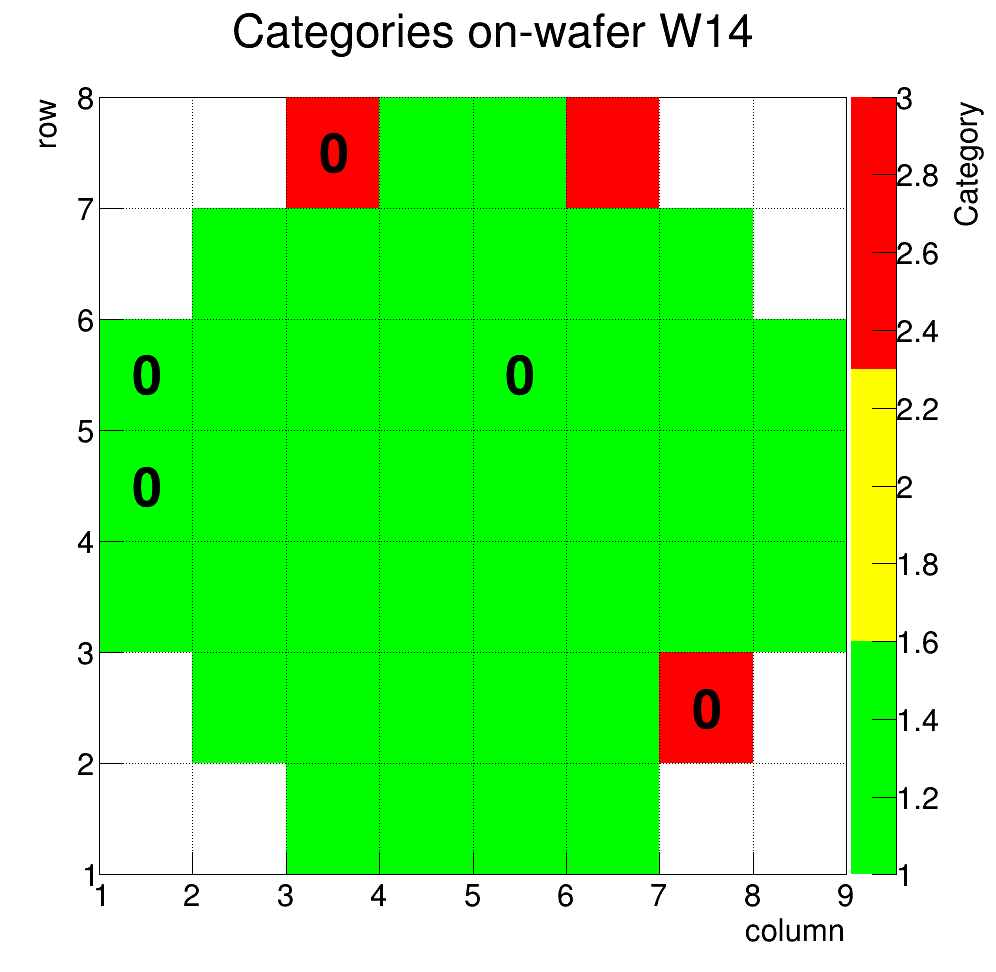

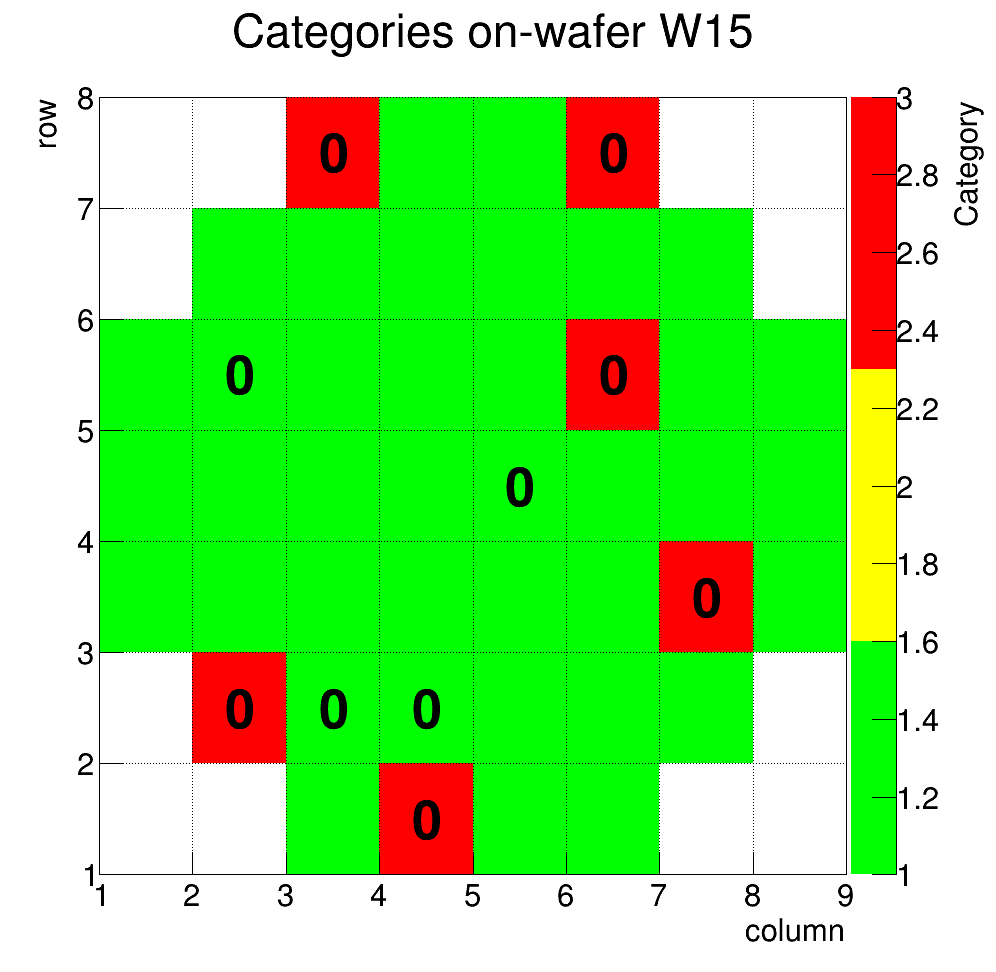

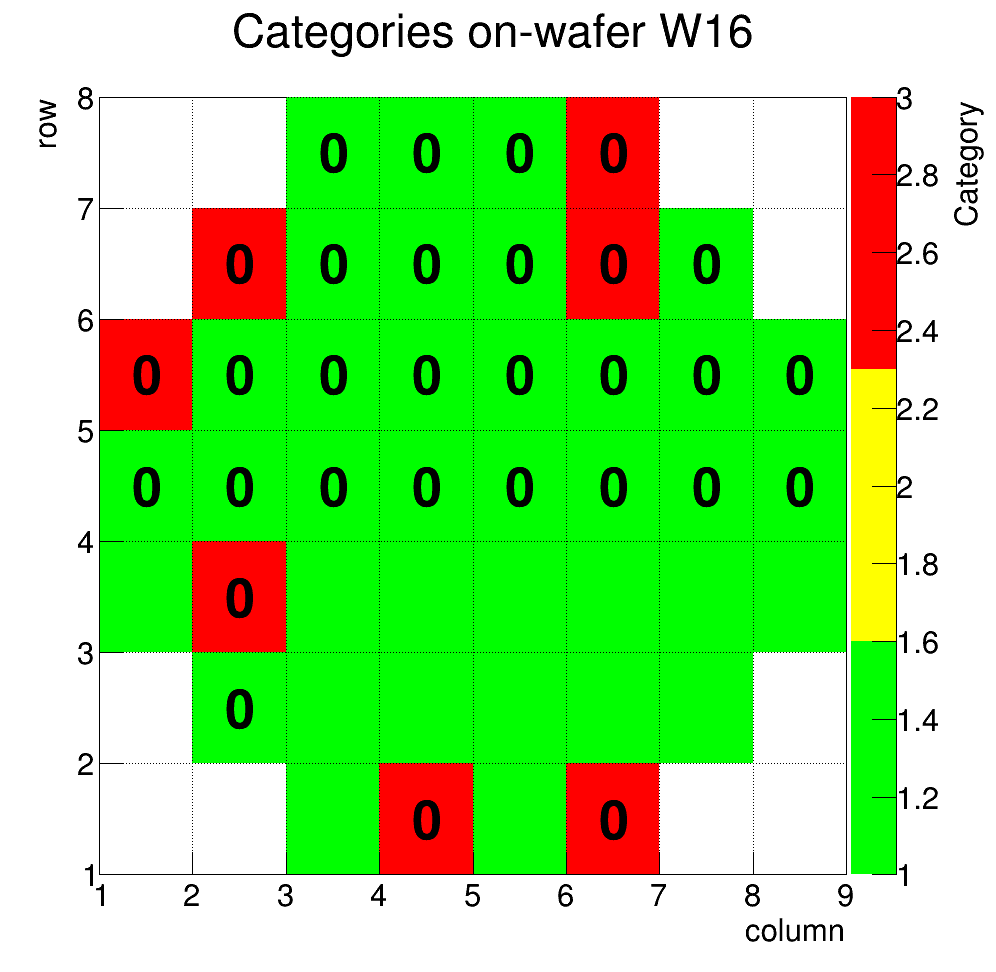

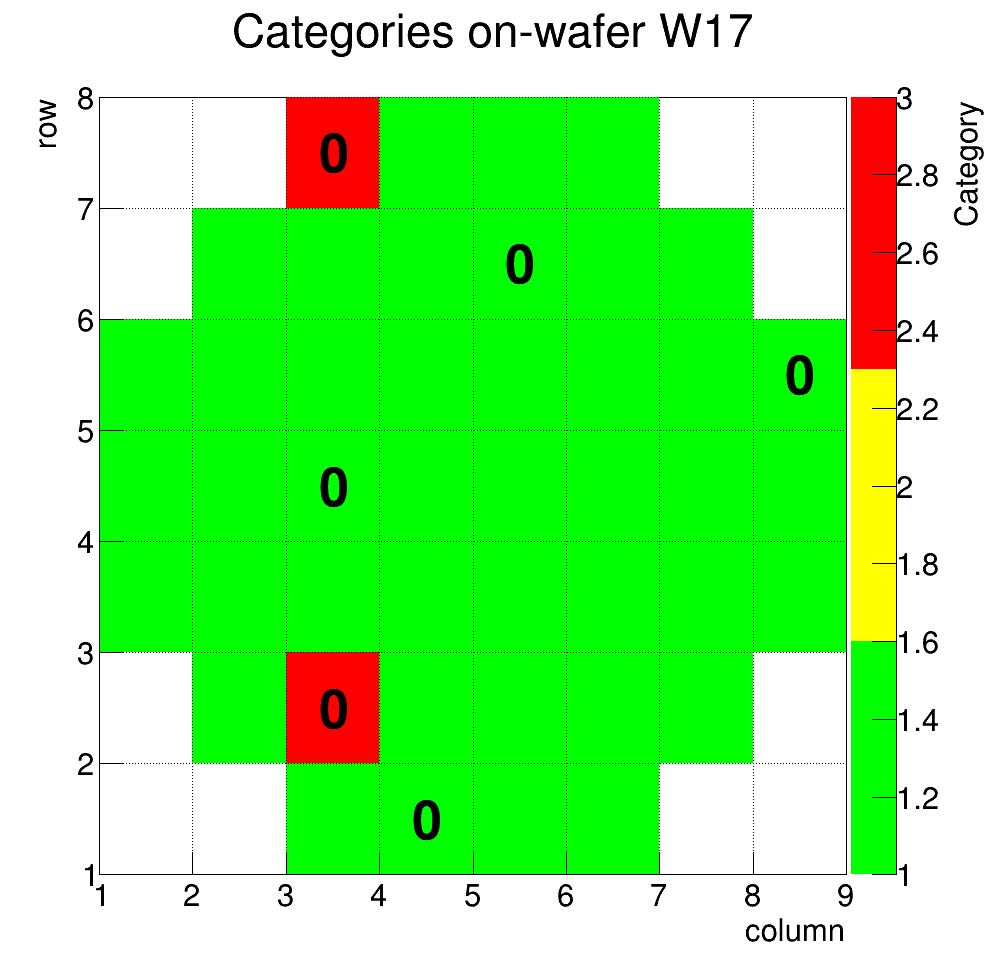

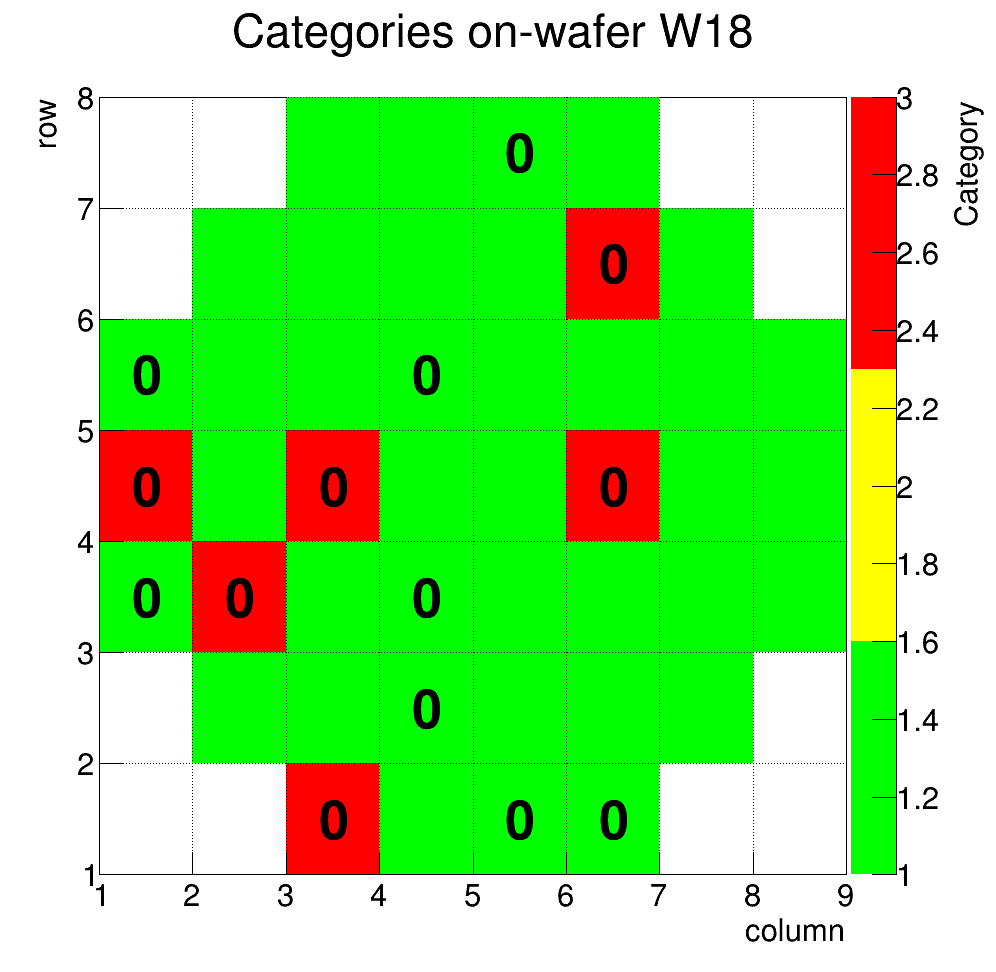

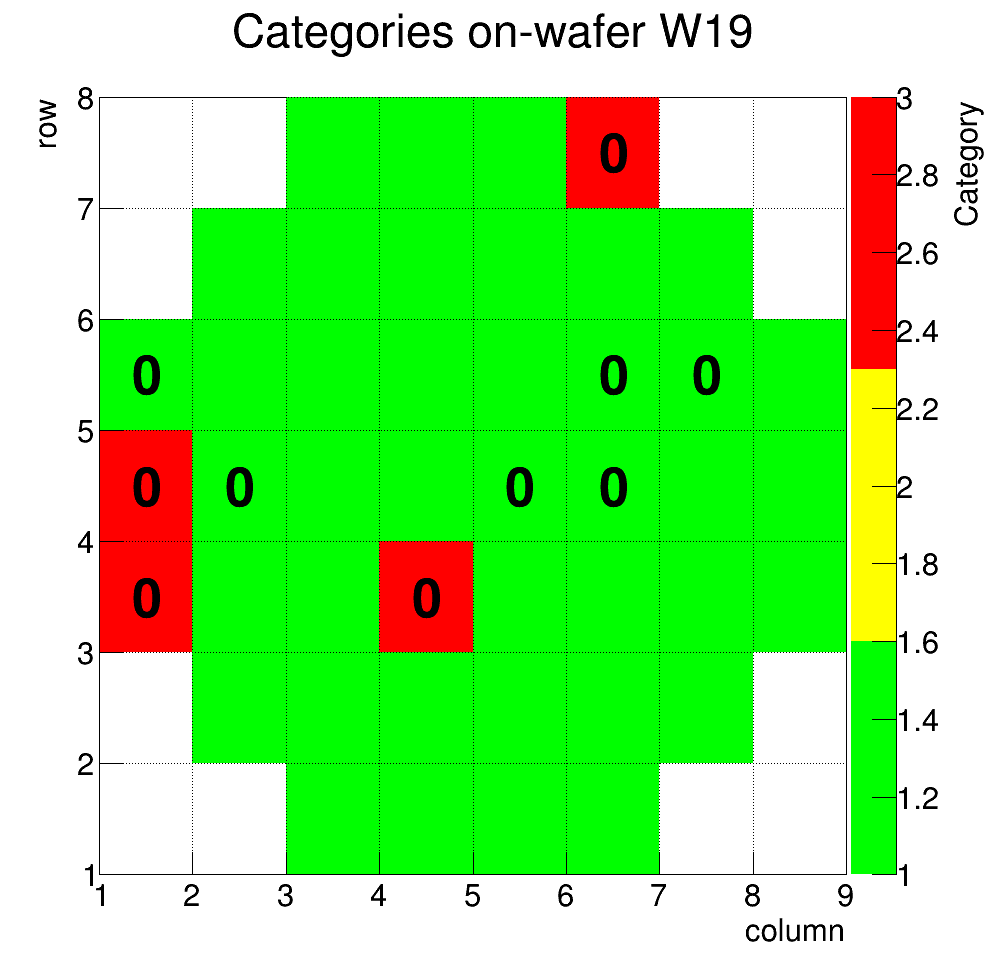

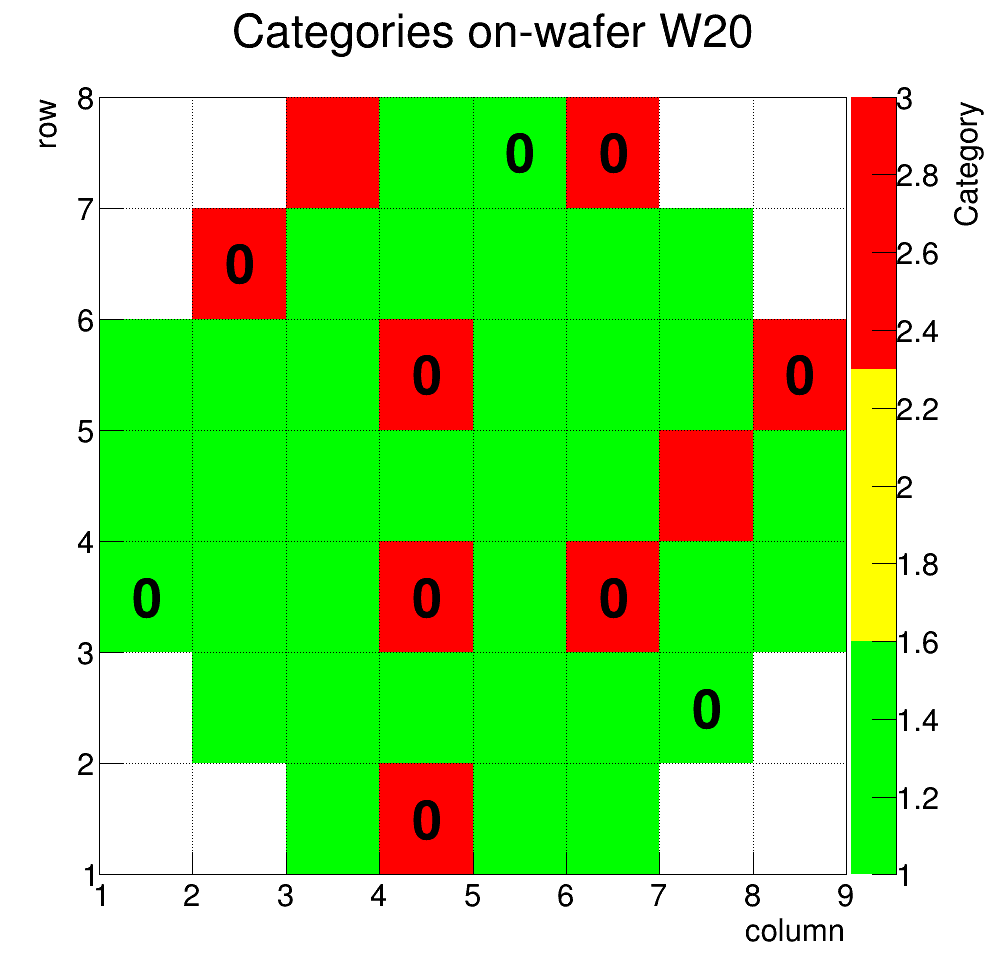

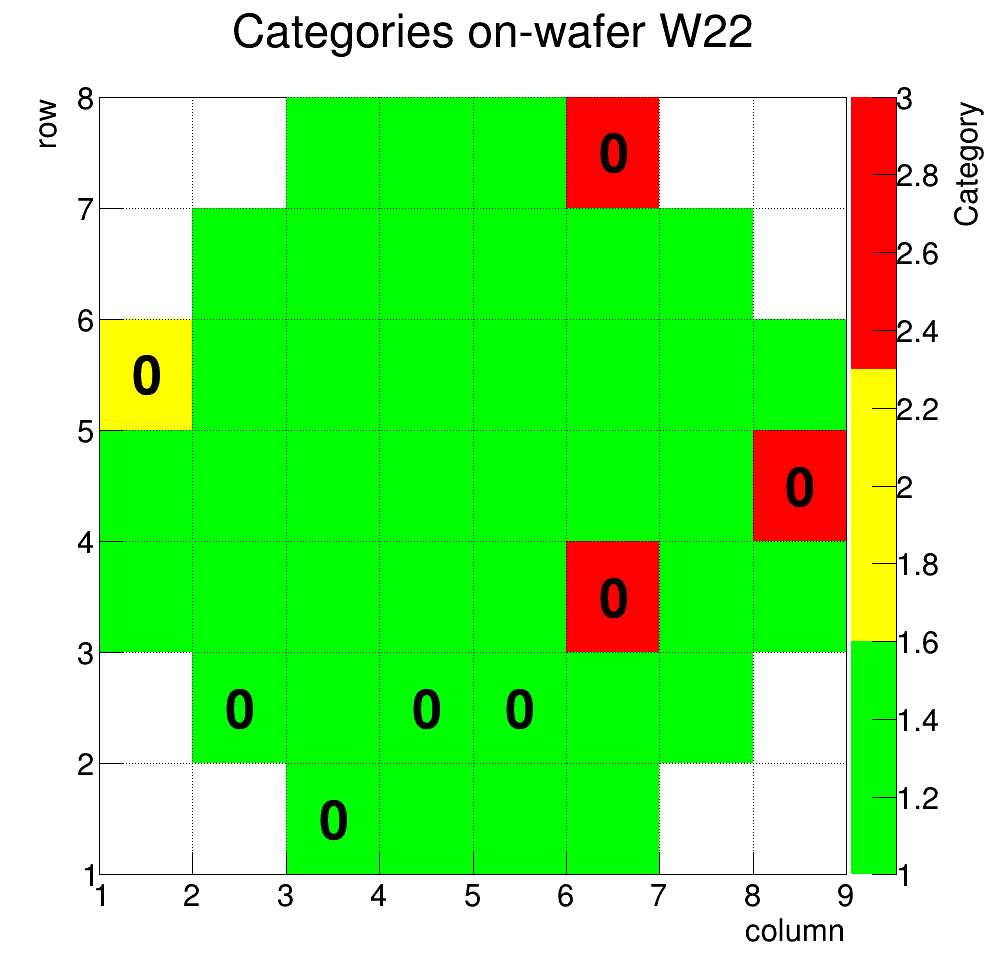

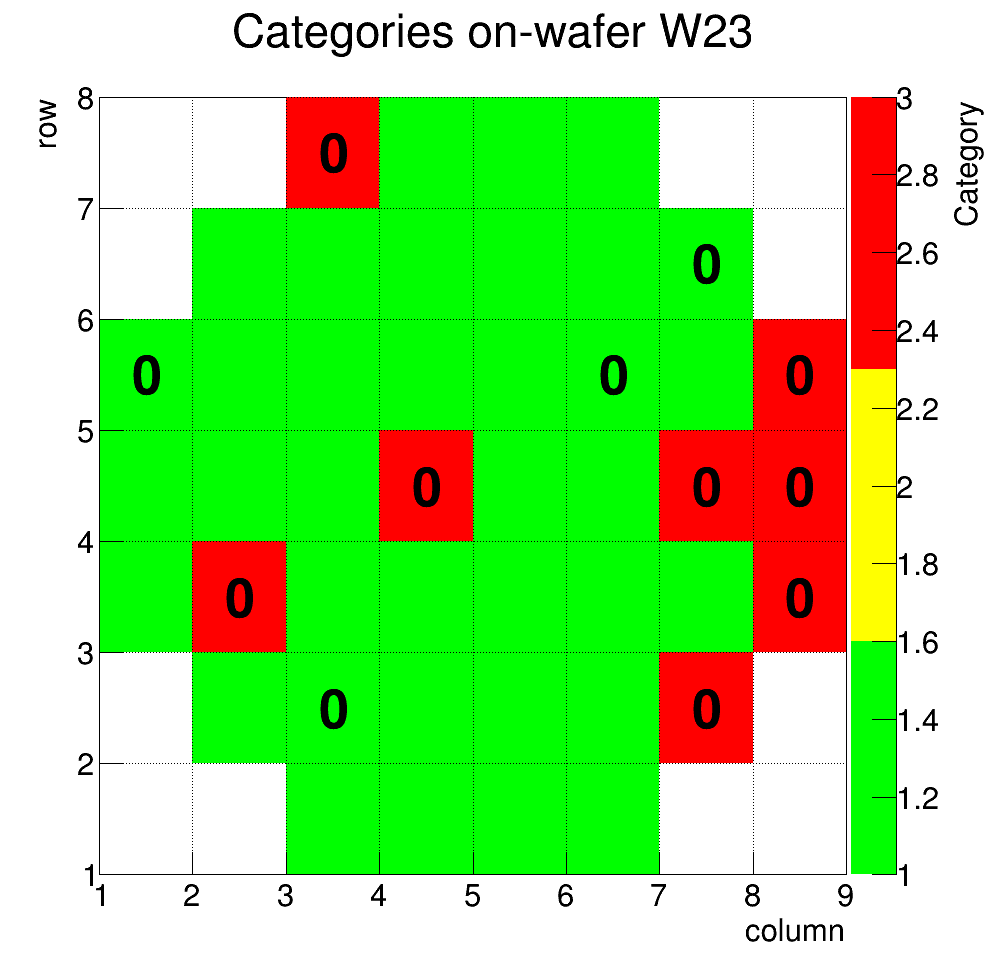

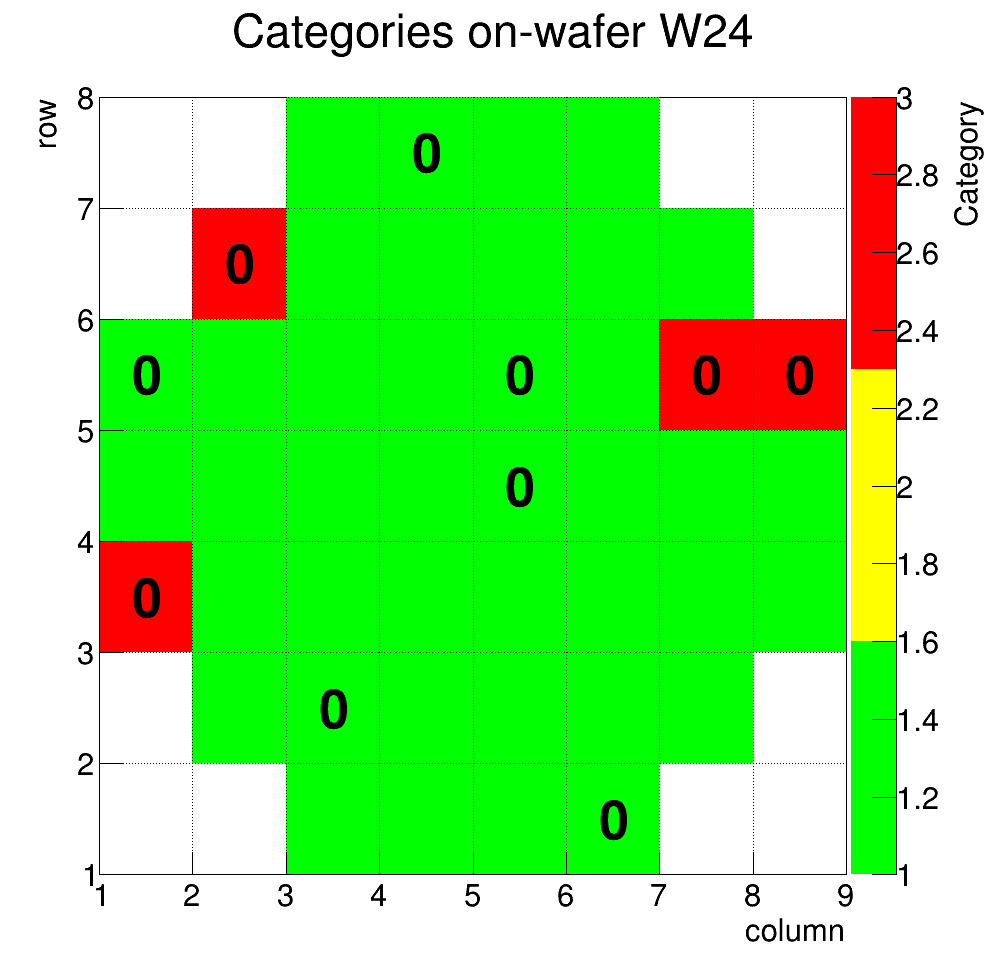

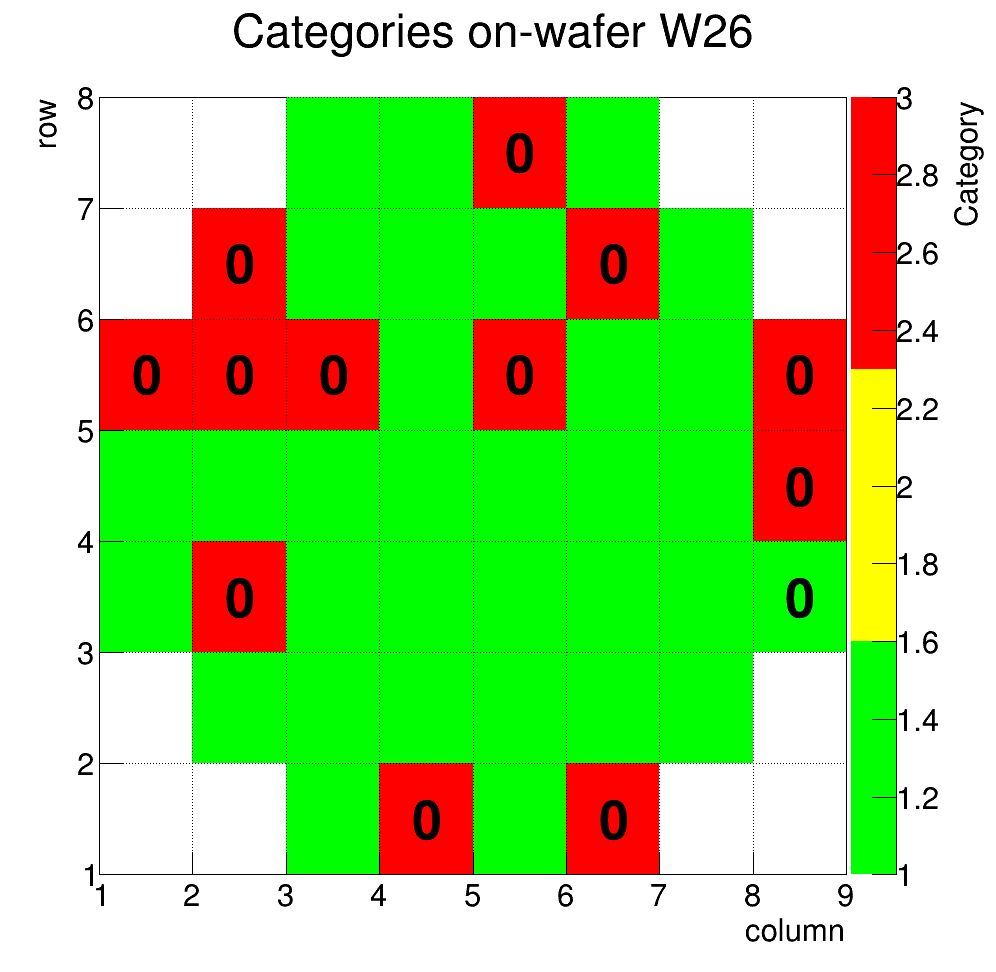

In [7]:
root.gStyle.SetPalette(3,palette)
cbump = []

for i in range(n_wafer):
    cbump.append(root.TCanvas("c_bump_W"+str(i+start_wafer), "c bump_W"+str(i+start_wafer), 1000,1000))

for i in range(n_wafer):
 if i in wafer_values:
 #if( i<20 ):
    hbump_qa[i].GetZaxis().SetRangeUser( 1, 3 )
    hbump_qa[i].GetZaxis().SetTitle("Category")
    hbump_qa[i].GetXaxis().SetTitle("column")
    hbump_qa[i].GetYaxis().SetTitle("row")

    #cbump.append(root.TCanvas("c_bump_W"+str(i+1), "c bump_W"+str(i+1), 1000,1000))
    cbump[i].SetRightMargin(0.15)
    cbump[i].cd()
    hnoisy_qa[i].SetMarkerSize(3)
    hbump_qa[i].Draw("colz")
    #hnoisy_qa[i].Draw("colz")
    root.gStyle.SetPaintTextFormat("X") 
    hnoisy_qa[i].Draw("TEXT same")
    root.gPad.SetGrid(1,1)
    root.gPad.Update()
    cbump[i].Update()
    hbump_qa[i].GetXaxis().SetNdivisions(n_col)
    hbump_qa[i].GetYaxis().SetNdivisions(n_row)
       
    if(save):
        #cbump[i].SaveAs(save_path+"categories/categories_W"+str(i+start_wafer)+".png" )
        #cbump[i].SaveAs(save_path+"categories/with_optical_inspection_marker/categories_W"+str(i+start_wafer)+".png" )
        cbump[i].SaveAs(save_path+"categories/with_final_grade_marker/categories_W"+str(i+start_wafer)+".png" )